# Training Analysis

Here we analyze the training progress of different model sizes. We look at loss, accuracy and full accuracy defined as a single puzzle being completely correct.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../models/gpt2_xl_00/metrics.csv")
df["time"] -= df["time"].iloc[0]
print("Best Results")
print(f"\t- Validation Loss: {df["valid_loss"].min():.6f}")
print(f"\t- Validation Accuracy: {df["valid_acc"].max():.3%}")
print(f"\t- Validation Full Accuracy: {df["valid_acc_full"].max():.3%}")

Best Results
	- Validation Loss: 0.001595
	- Validation Accuracy: 99.950%
	- Validation Full Accuracy: 98.926%


## Loss Curves

In [36]:
ewm_span = 10

df1 = pd.read_csv("../models/gpt2_md_00/metrics.csv")
df2 = pd.read_csv("../models/gpt2_lg_00/metrics.csv")
df3 = pd.read_csv("../models/gpt2_xl_00/metrics.csv")

df1["time"] -= df1["time"].iloc[0]
df2["time"] -= df2["time"].iloc[0]
df3["time"] -= df3["time"].iloc[0]

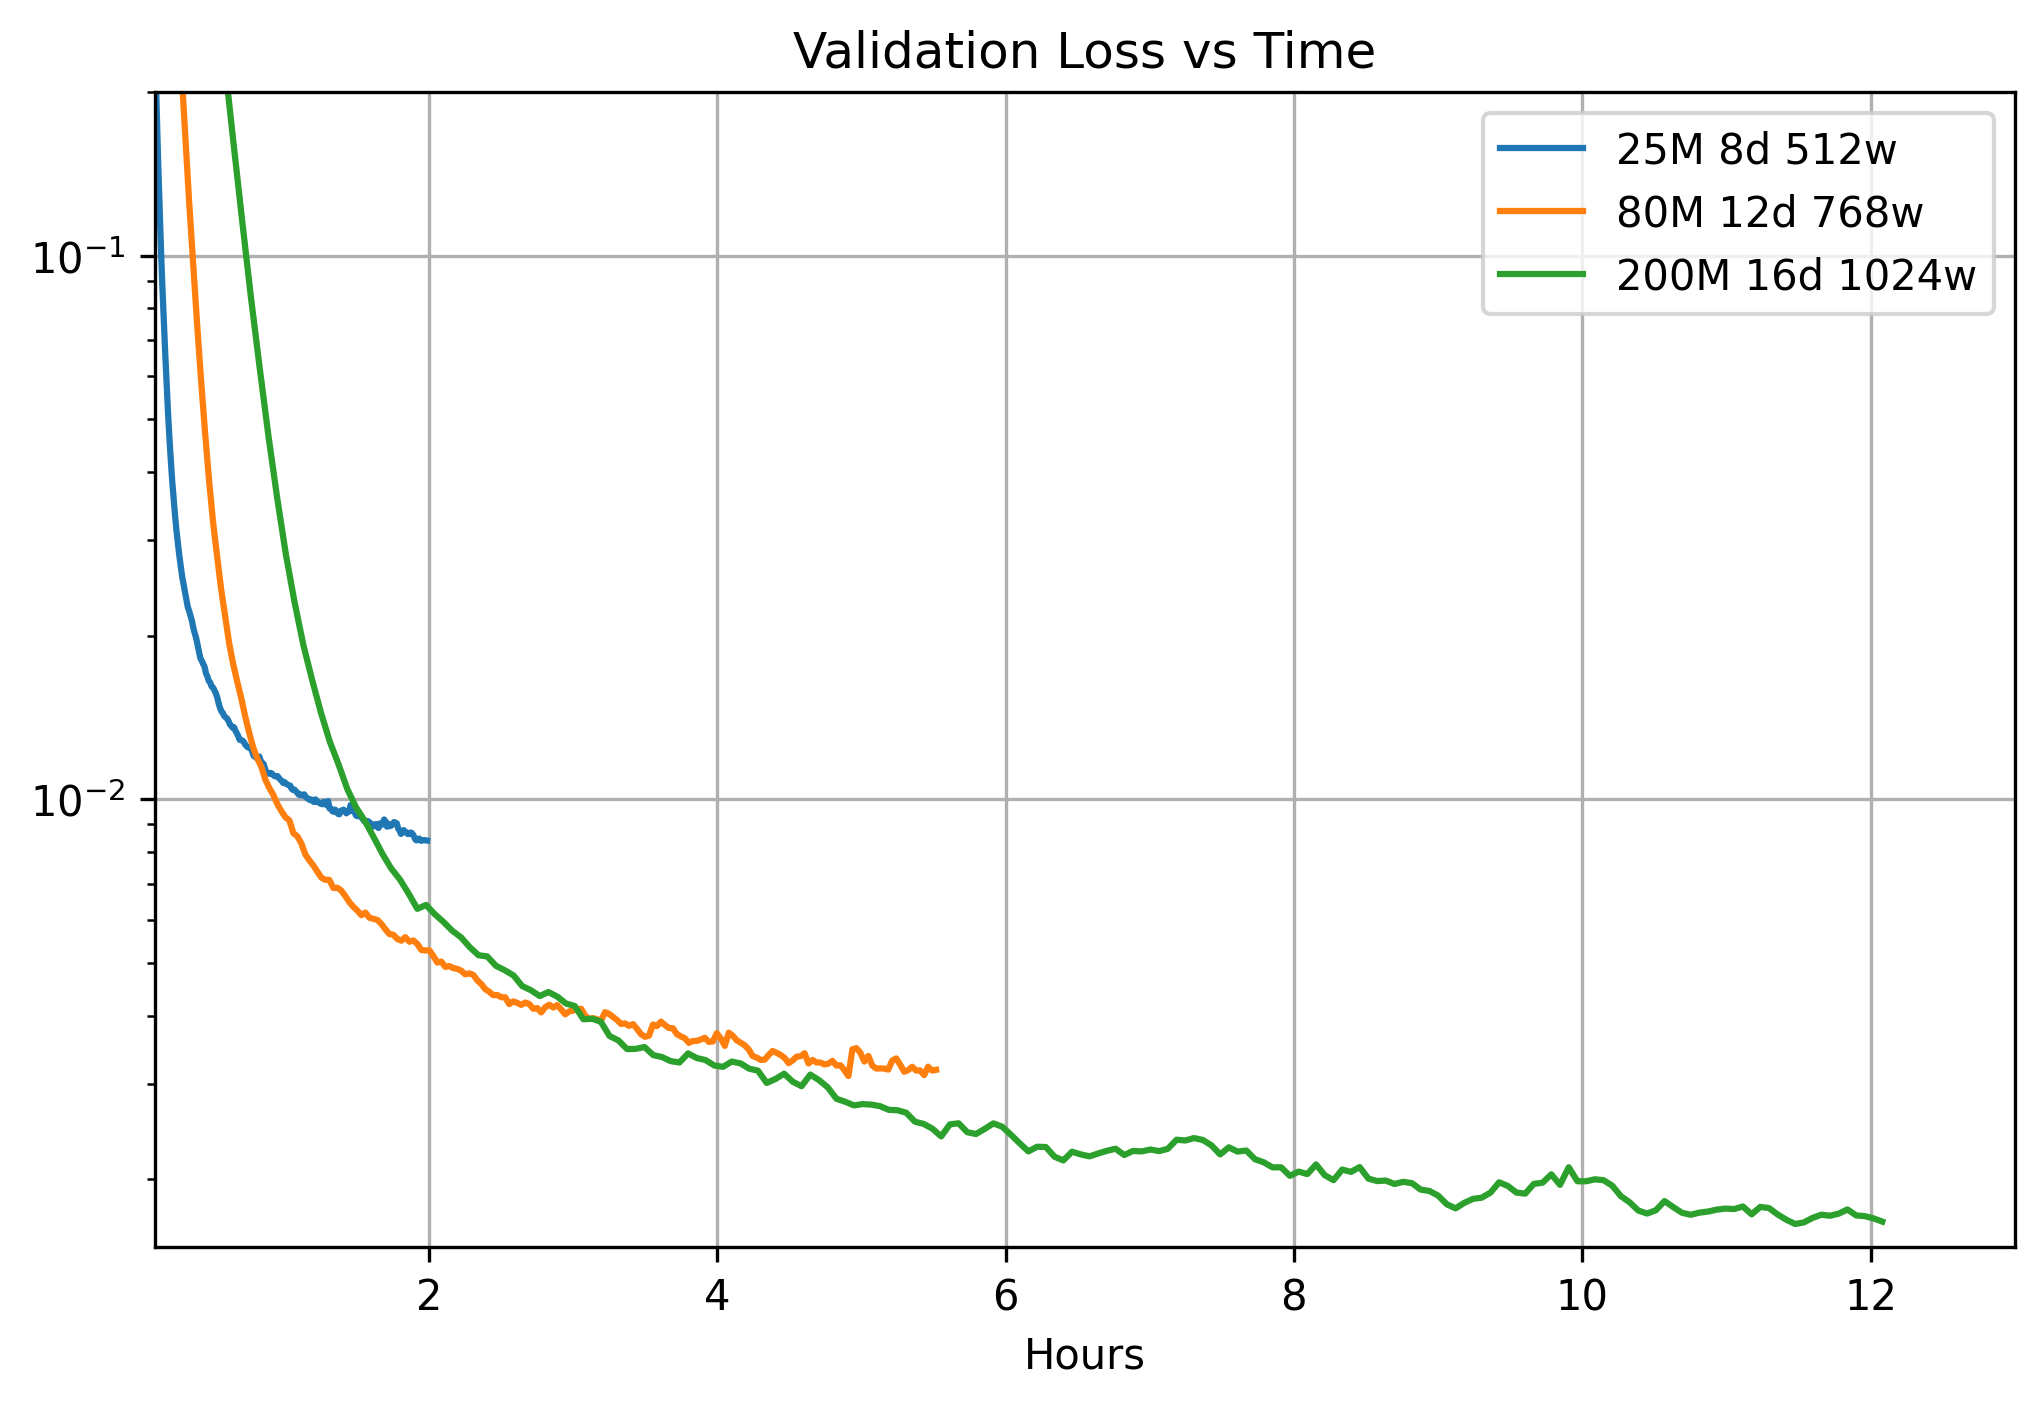

In [46]:
plt.figure(dpi=300, figsize=(8, 5))
plt.title("Validation Loss vs Time")
plt.plot(df1["time"] / 3600, df1["valid_loss"].ewm(span=ewm_span).mean(), label="25M 8d 512w")
plt.plot(df2["time"] / 3600, df2["valid_loss"].ewm(span=ewm_span).mean(), label="80M 12d 768w")
plt.plot(df3["time"] / 3600, df3["valid_loss"].ewm(span=ewm_span).mean(), label="200M 16d 1024w")
plt.yscale("log")
plt.xlabel("Hours")
# plt.xscale("log")
plt.ylim(1.5e-3, 2e-1)
plt.xlim(0.1, 13)
plt.legend()
plt.grid()
plt.savefig("../img/valid_loss_time.png")
plt.show()

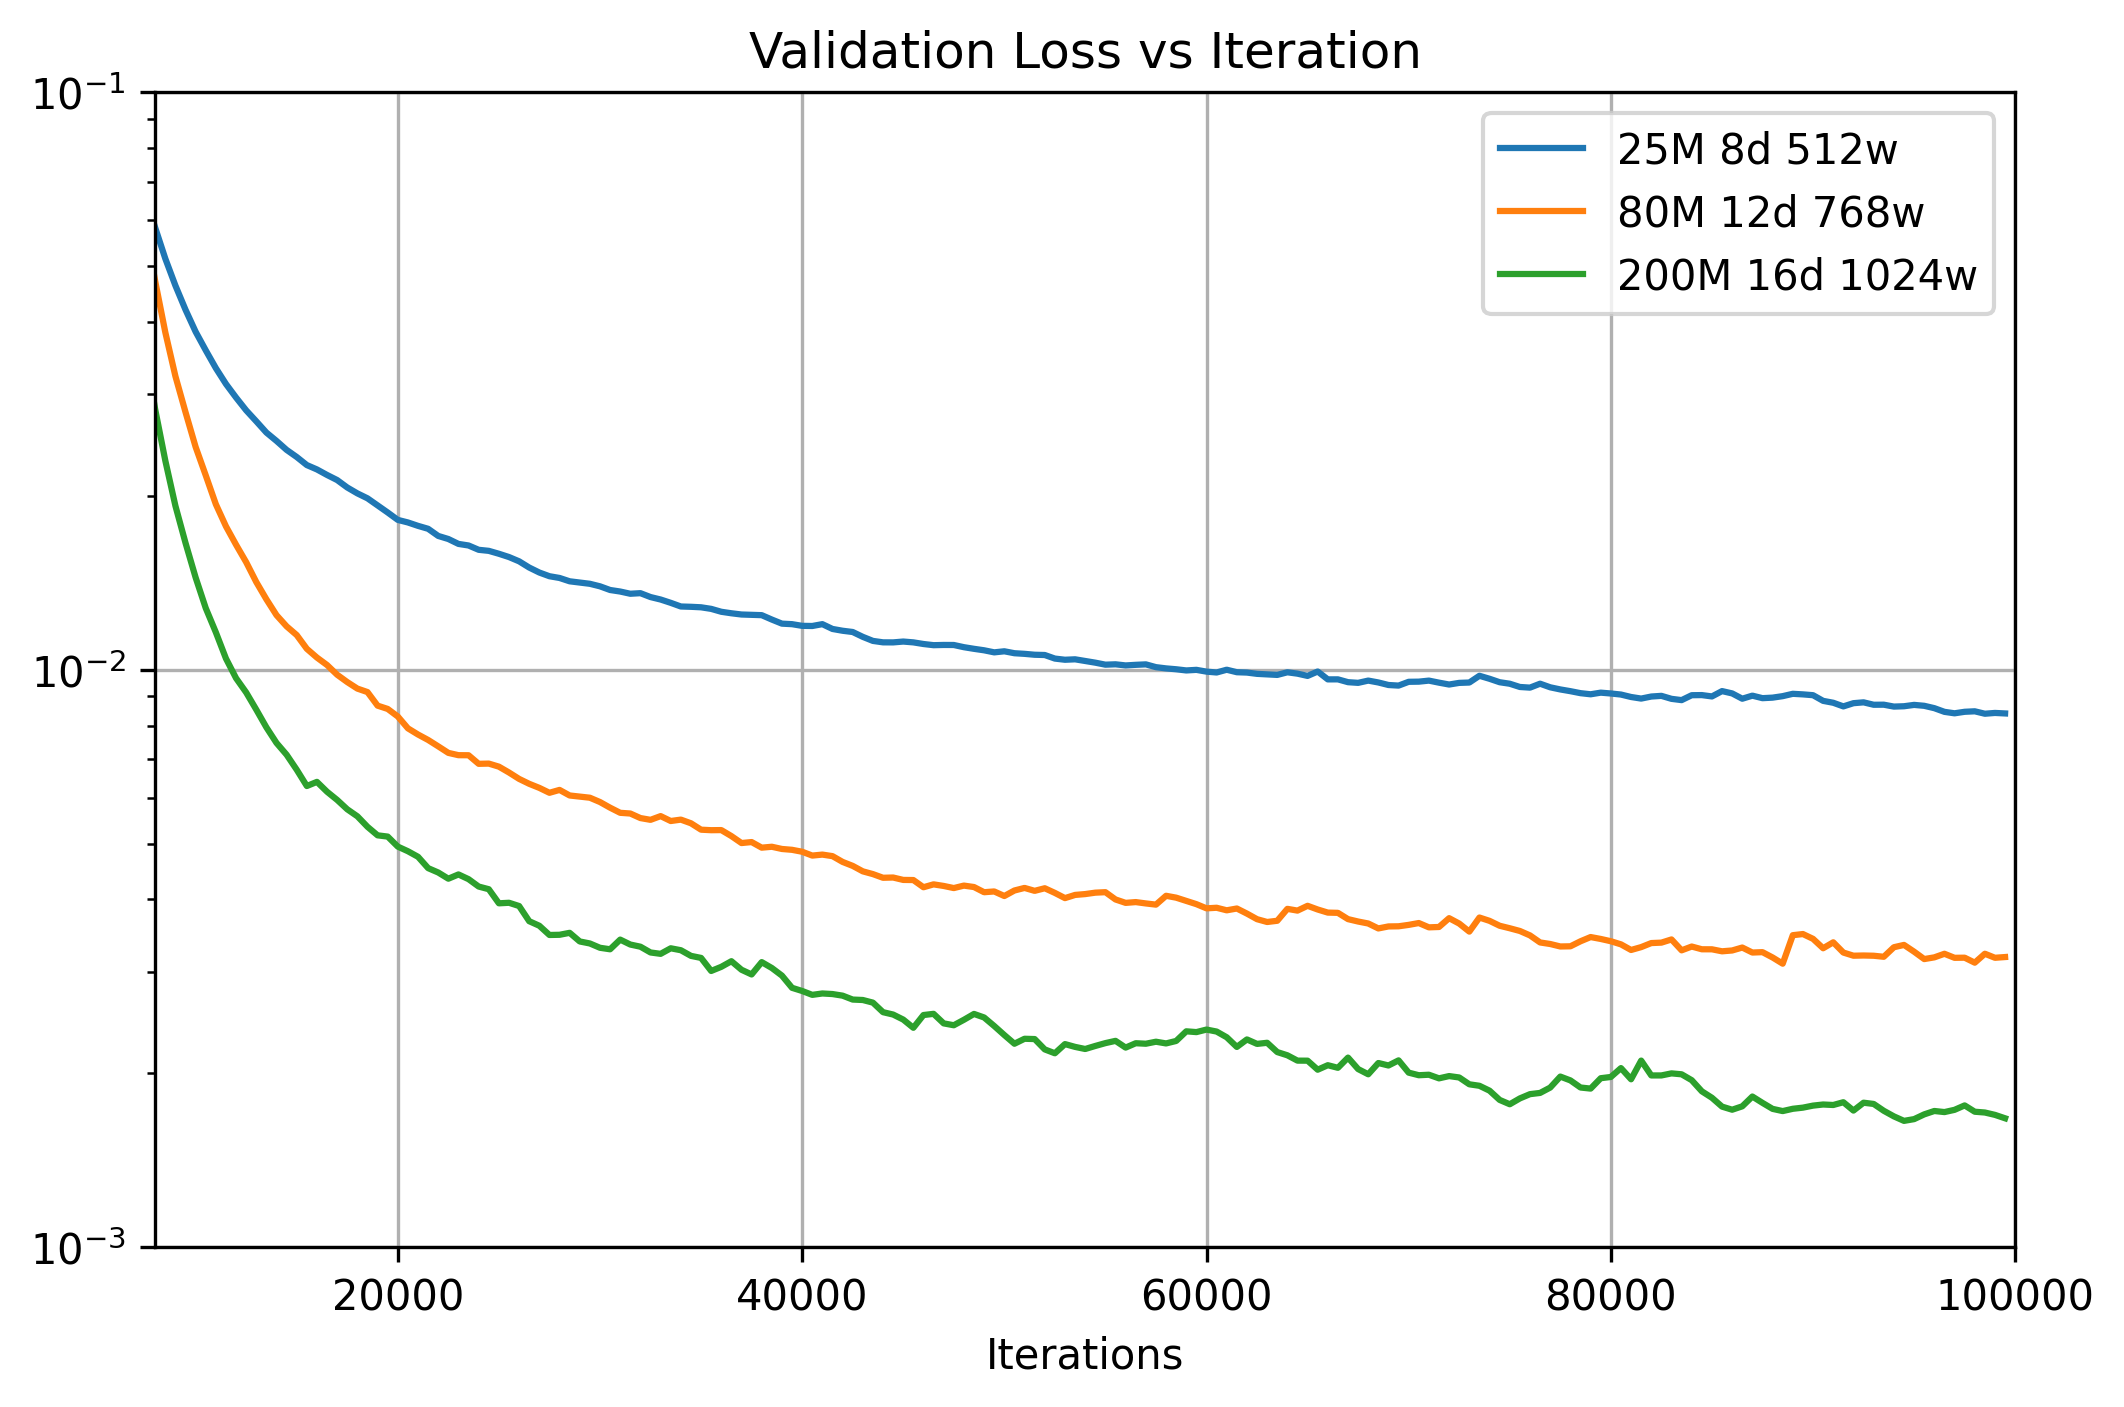

In [47]:
plt.figure(dpi=300, figsize=(8, 5))
plt.title("Validation Loss vs Iteration")
plt.plot(df1["iter"], df1["valid_loss"].ewm(span=ewm_span).mean(), label="25M 8d 512w")
plt.plot(df2["iter"], df2["valid_loss"].ewm(span=ewm_span).mean(), label="80M 12d 768w")
plt.plot(df3["iter"], df3["valid_loss"].ewm(span=ewm_span).mean(), label="200M 16d 1024w")
plt.yscale("log")
# plt.xscale("log")
plt.xlabel("Iterations")
plt.legend()
plt.grid()
plt.ylim(1e-3, 1e-1)
plt.xlim(8e+3, 1e+5)
plt.savefig("../img/valid_loss_iter.png")
plt.show()

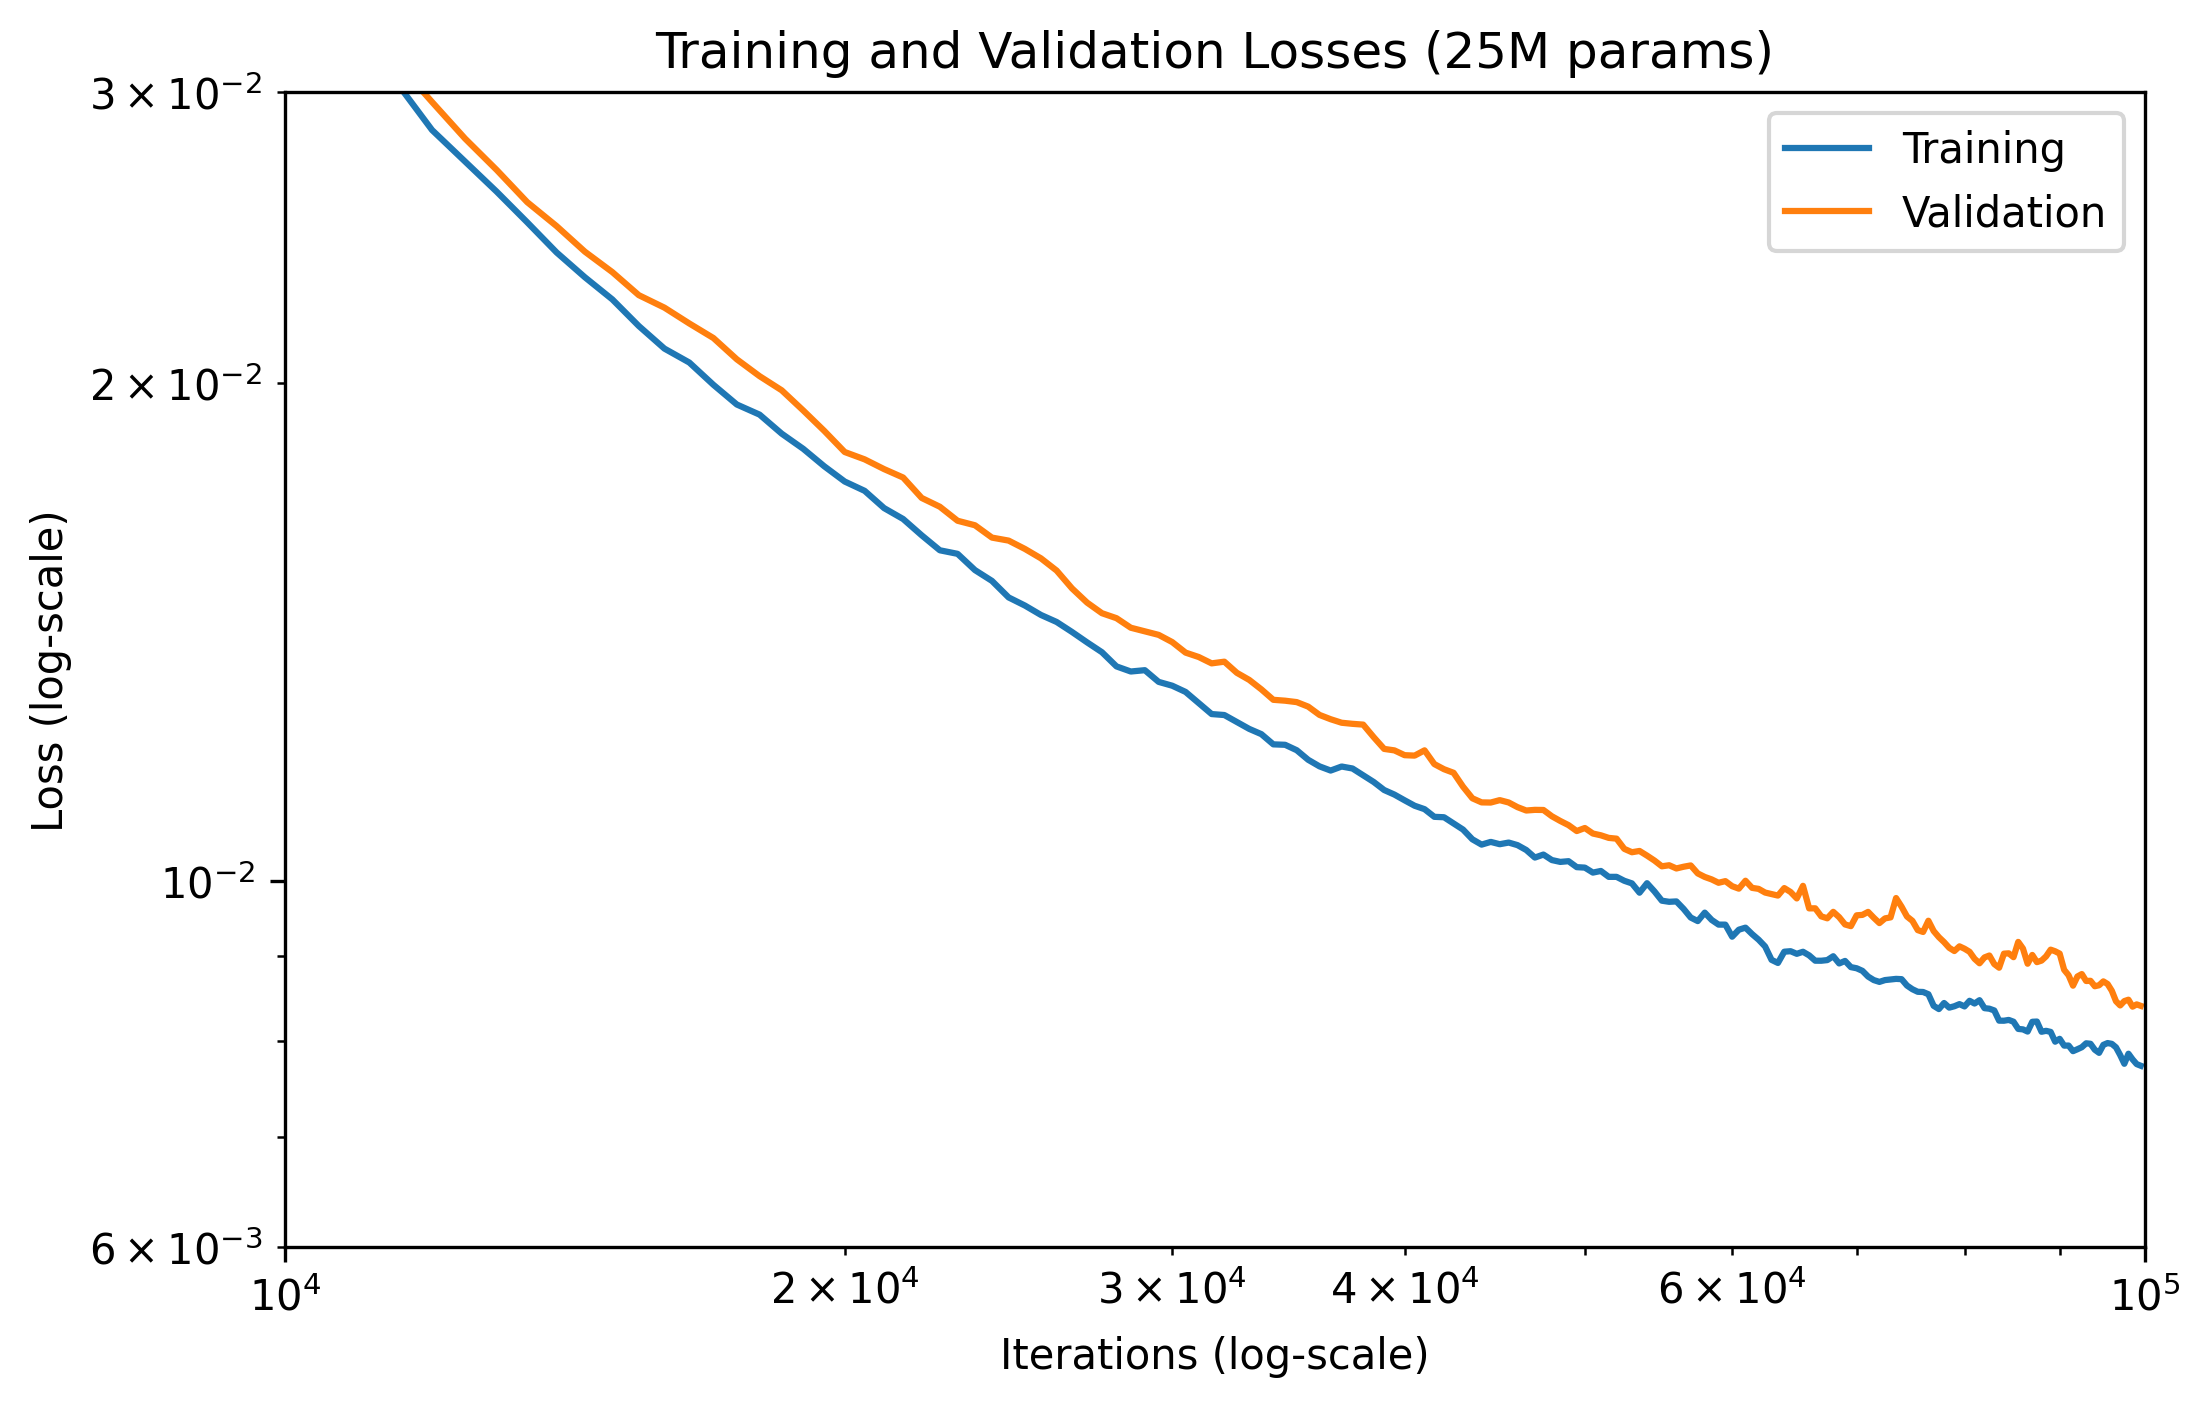

In [63]:
df = pd.read_csv("../models/gpt2_md_00/metrics.csv")
ewm_span = 5

plt.figure(dpi=300, figsize=(8, 5))
plt.title("Training and Validation Losses (25M params)")
plt.plot(df["iter"], df["train_loss"].ewm(span=ewm_span).mean(), label="Training")
plt.plot(df["iter"], df["valid_loss"].ewm(span=ewm_span).mean(), label="Validation")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.ylim(6e-3, 3e-2)
plt.xlim(1e+4, 1e+5)
plt.xlabel("Iterations (log-scale)")
plt.ylabel("Loss (log-scale)")
plt.savefig("../img/loss_iter_25m.png")
plt.show()

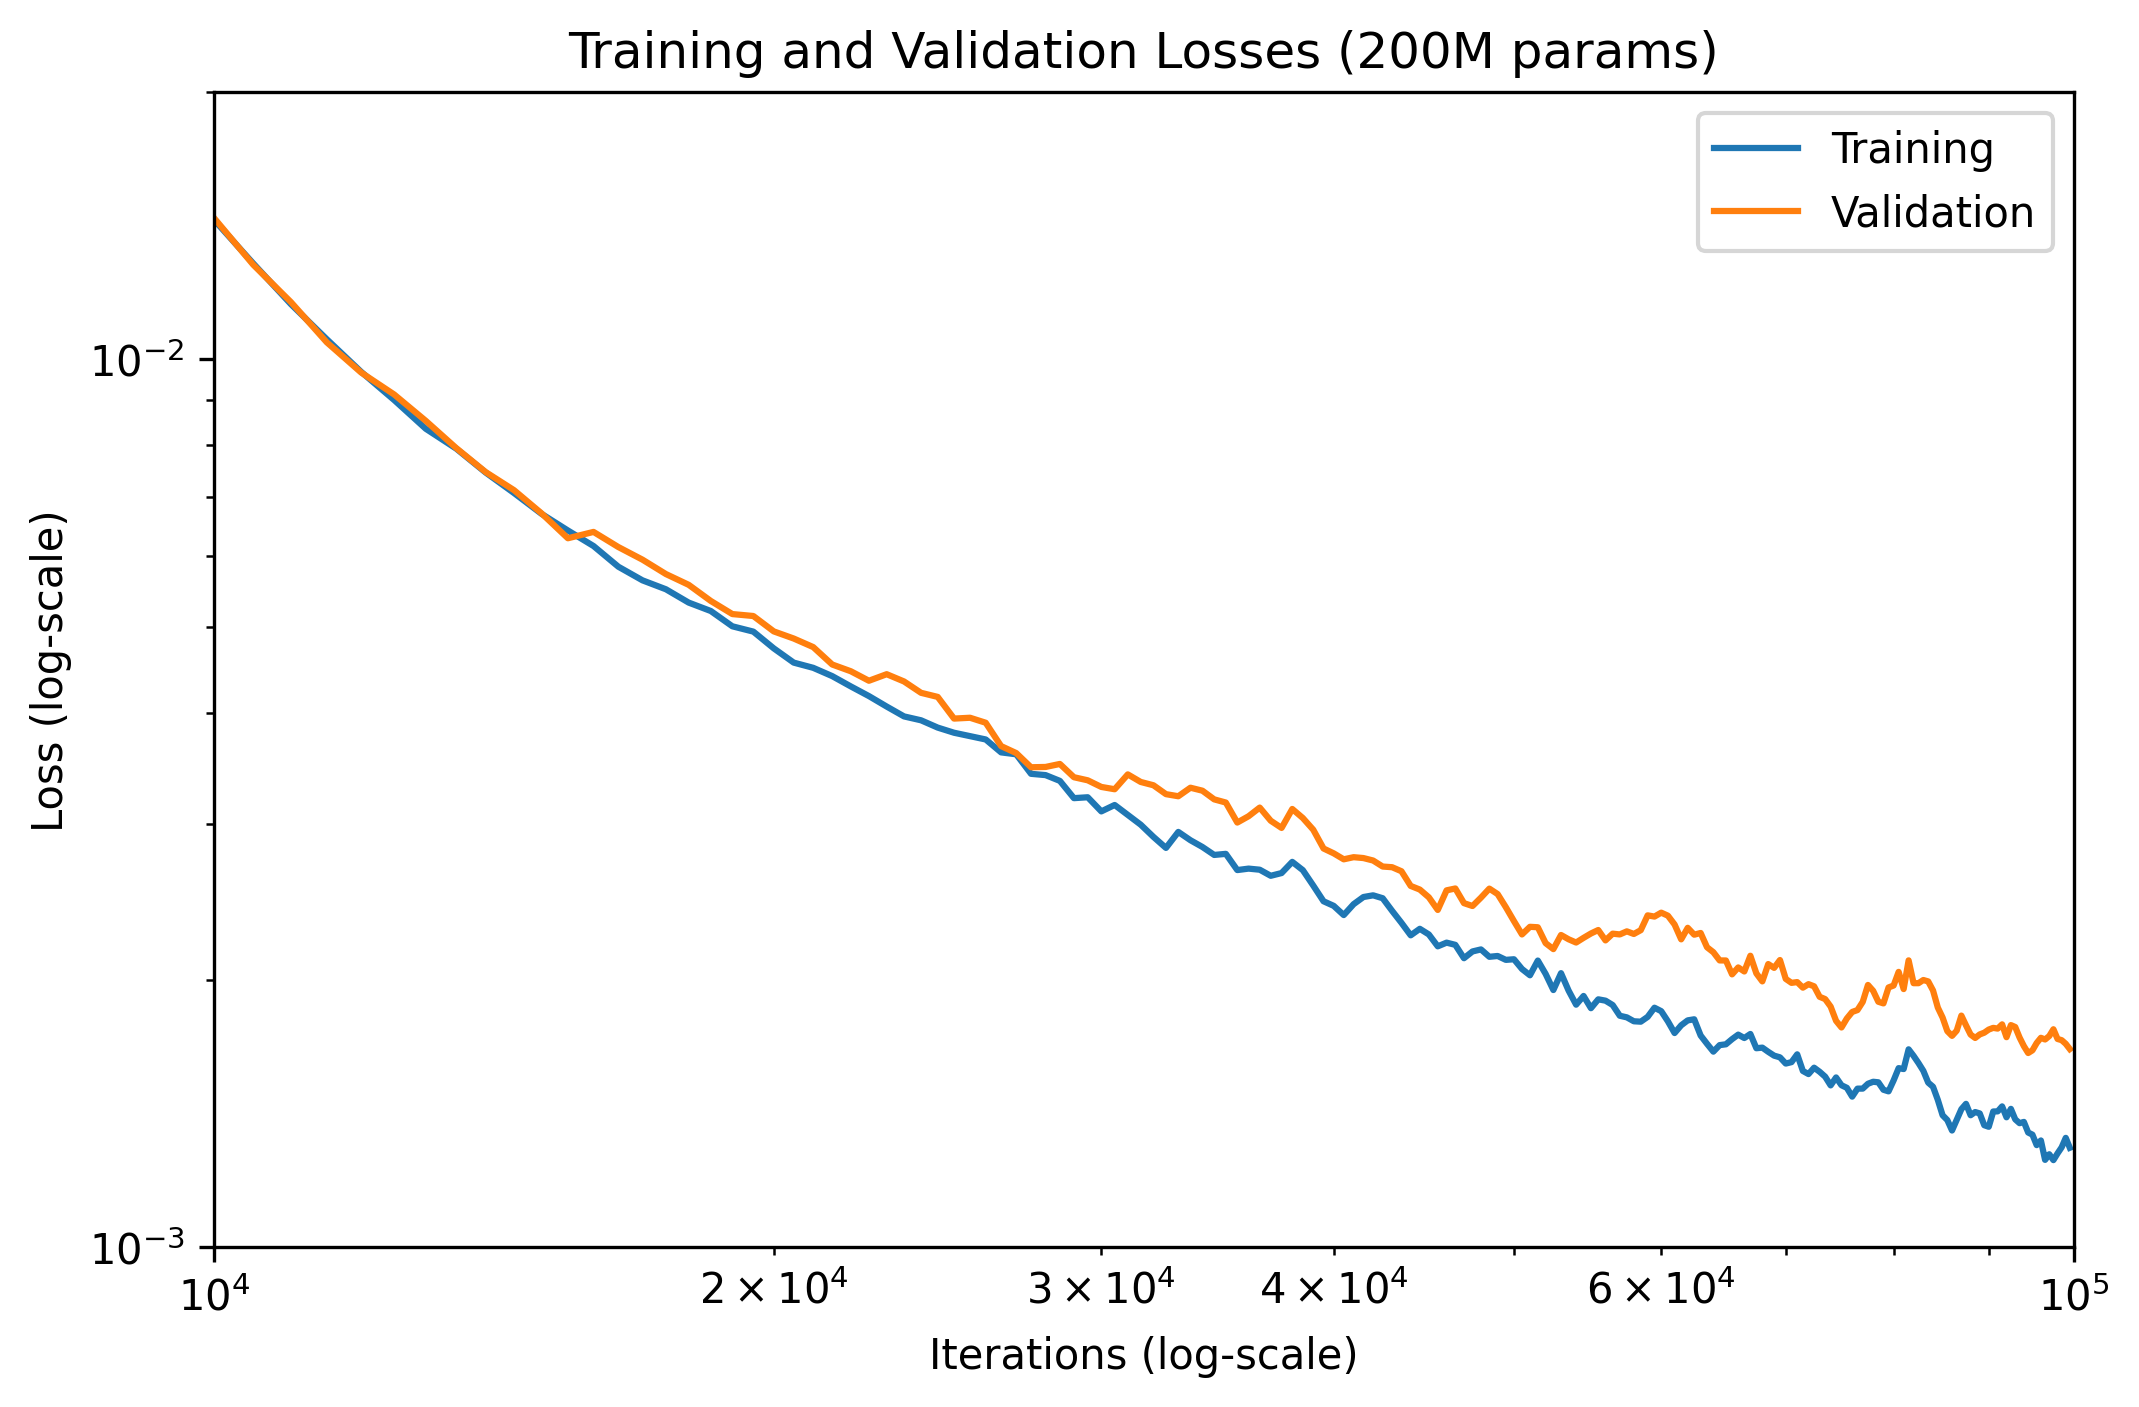

In [58]:
df = pd.read_csv("../models/gpt2_xl_00/metrics.csv")
ewm_span = 5

plt.figure(dpi=300, figsize=(8, 5))
plt.title("Training and Validation Losses (200M params)")
plt.plot(df["iter"], df["train_loss"].ewm(span=ewm_span).mean(), label="Training")
plt.plot(df["iter"], df["valid_loss"].ewm(span=ewm_span).mean(), label="Validation")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.ylim(1e-3, 2e-2)
plt.xlim(1e+4, 1e+5)
plt.xlabel("Iterations (log-scale)")
plt.ylabel("Loss (log-scale)")
plt.savefig("../img/loss_iter_200m.png")
plt.show()

## Error (Inverse Accuracy) curves

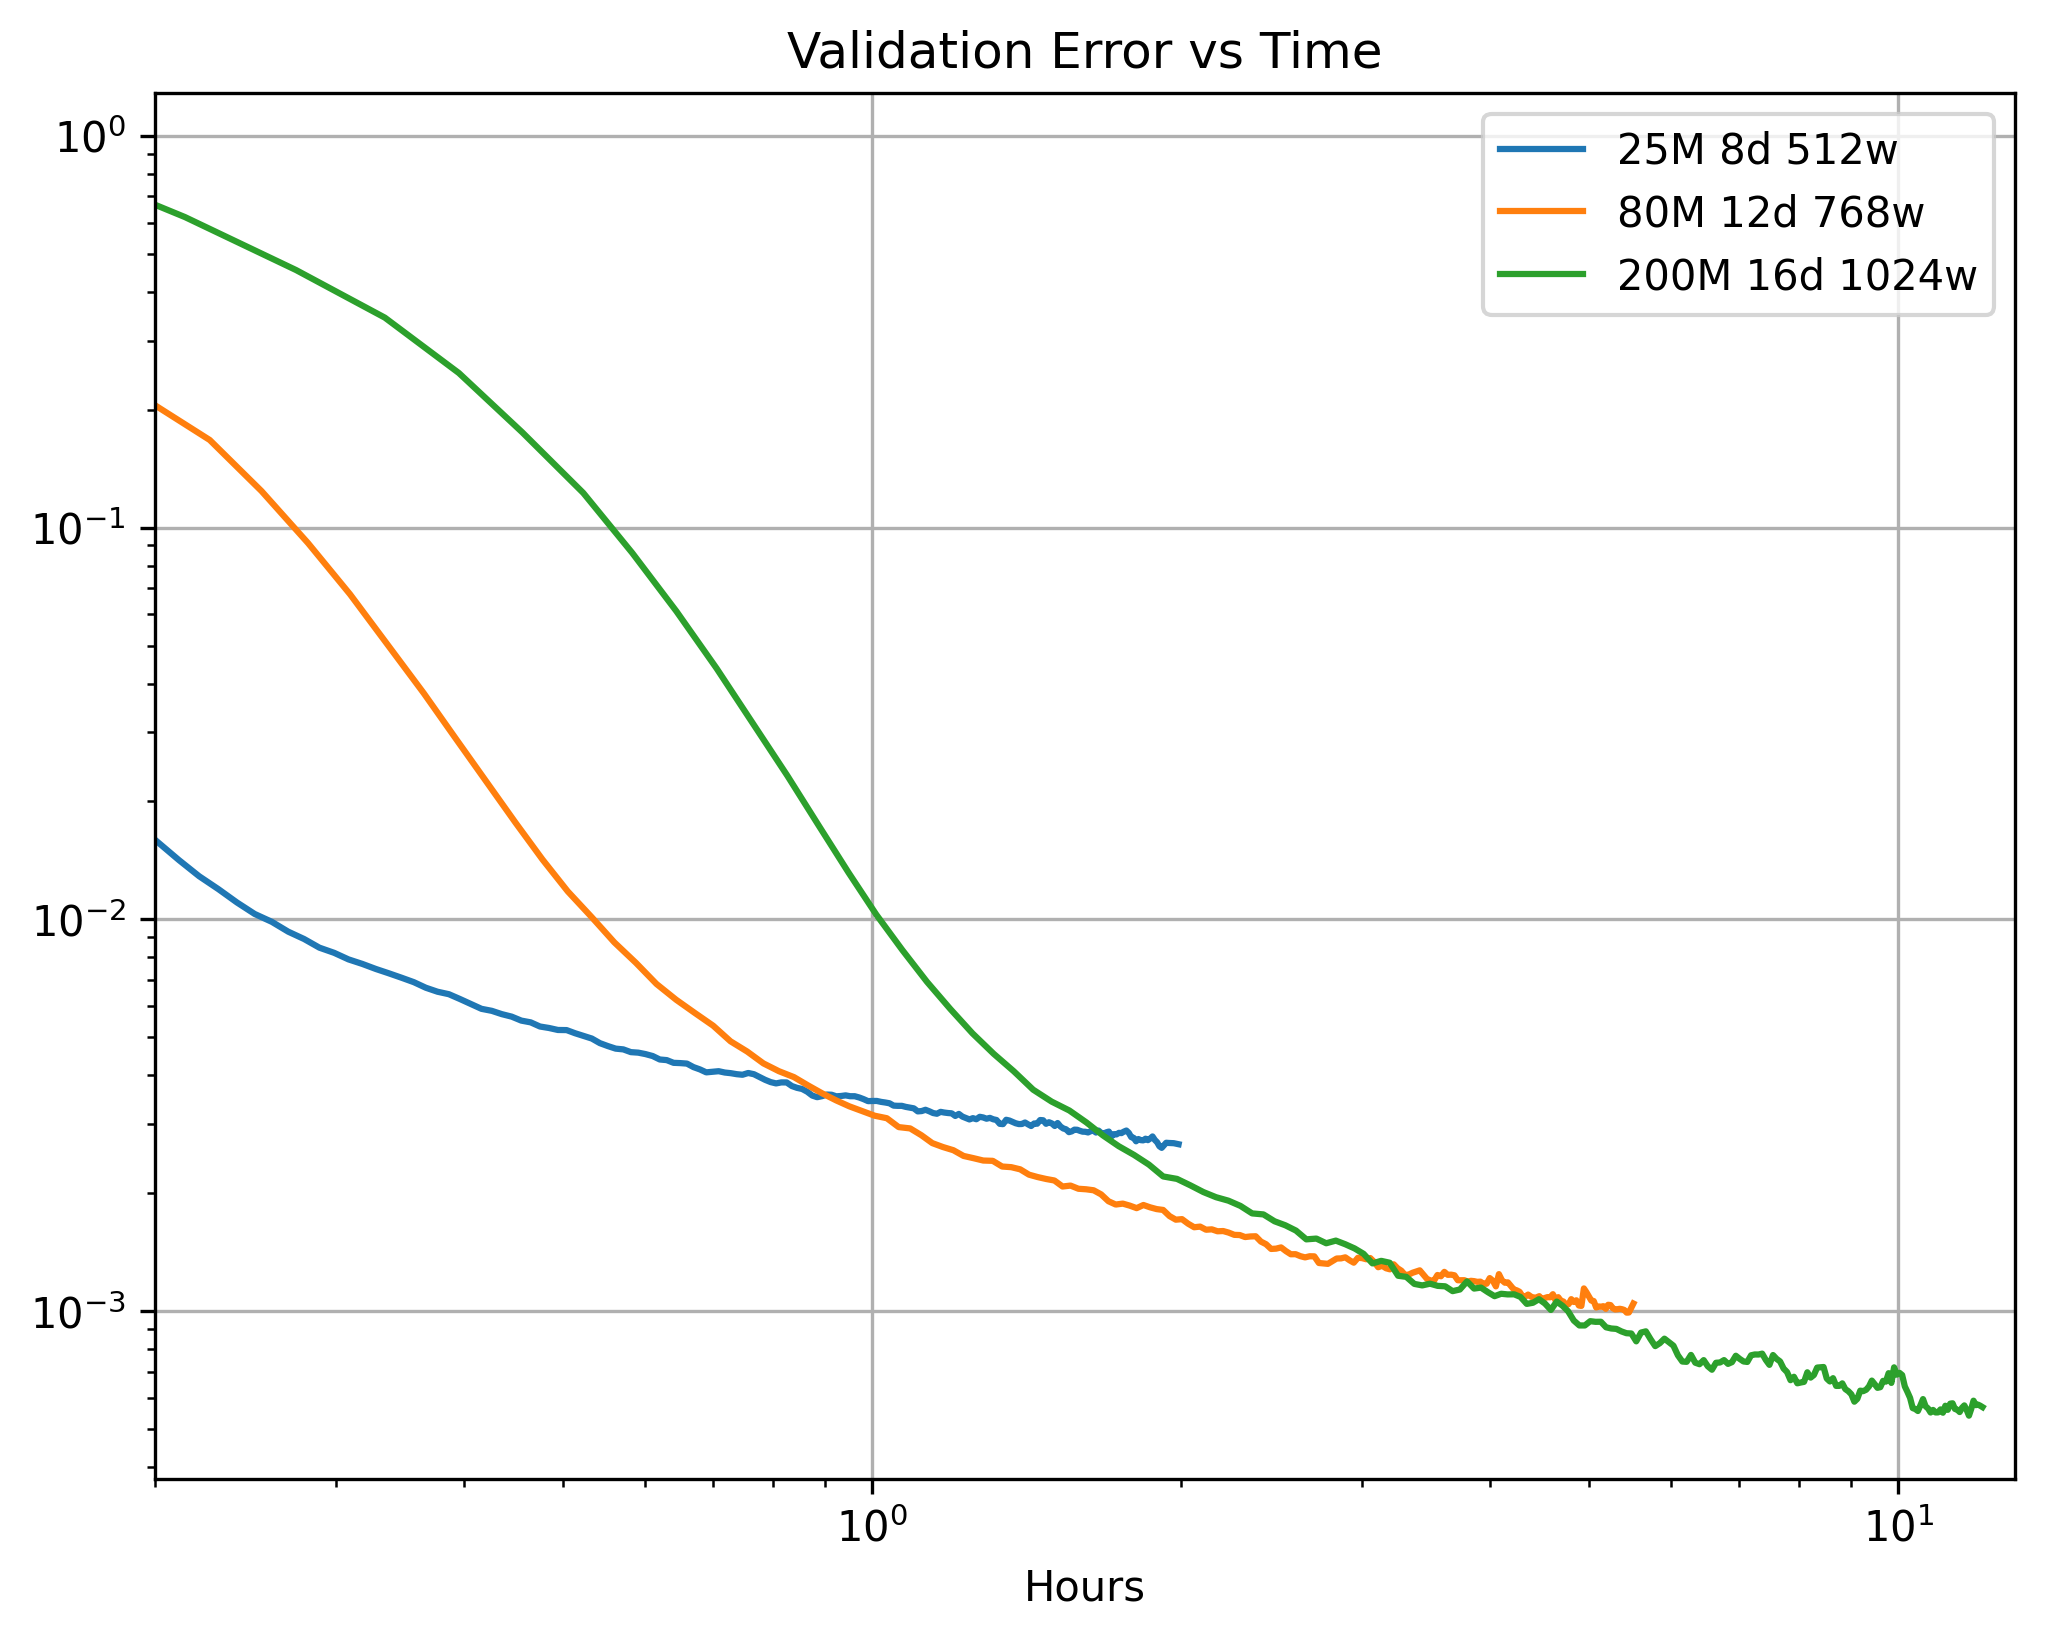

In [53]:
plt.figure(dpi=300, figsize=(8, 6))
plt.title("Validation Error vs Time")
plt.plot(df1["time"] / 3600, 1 - df1["valid_acc"].ewm(span=ewm_span).mean(), label="25M 8d 512w")
plt.plot(df2["time"] / 3600, 1 - df2["valid_acc"].ewm(span=ewm_span).mean(), label="80M 12d 768w")
plt.plot(df3["time"] / 3600, 1 - df3["valid_acc"].ewm(span=ewm_span).mean(), label="200M 16d 1024w")
plt.yscale("log")
plt.xlabel("Hours")
plt.xscale("log")
plt.xlim(0.2, 13)
plt.legend()
plt.grid()
plt.savefig("../img/valid_error_time.png")
plt.show()

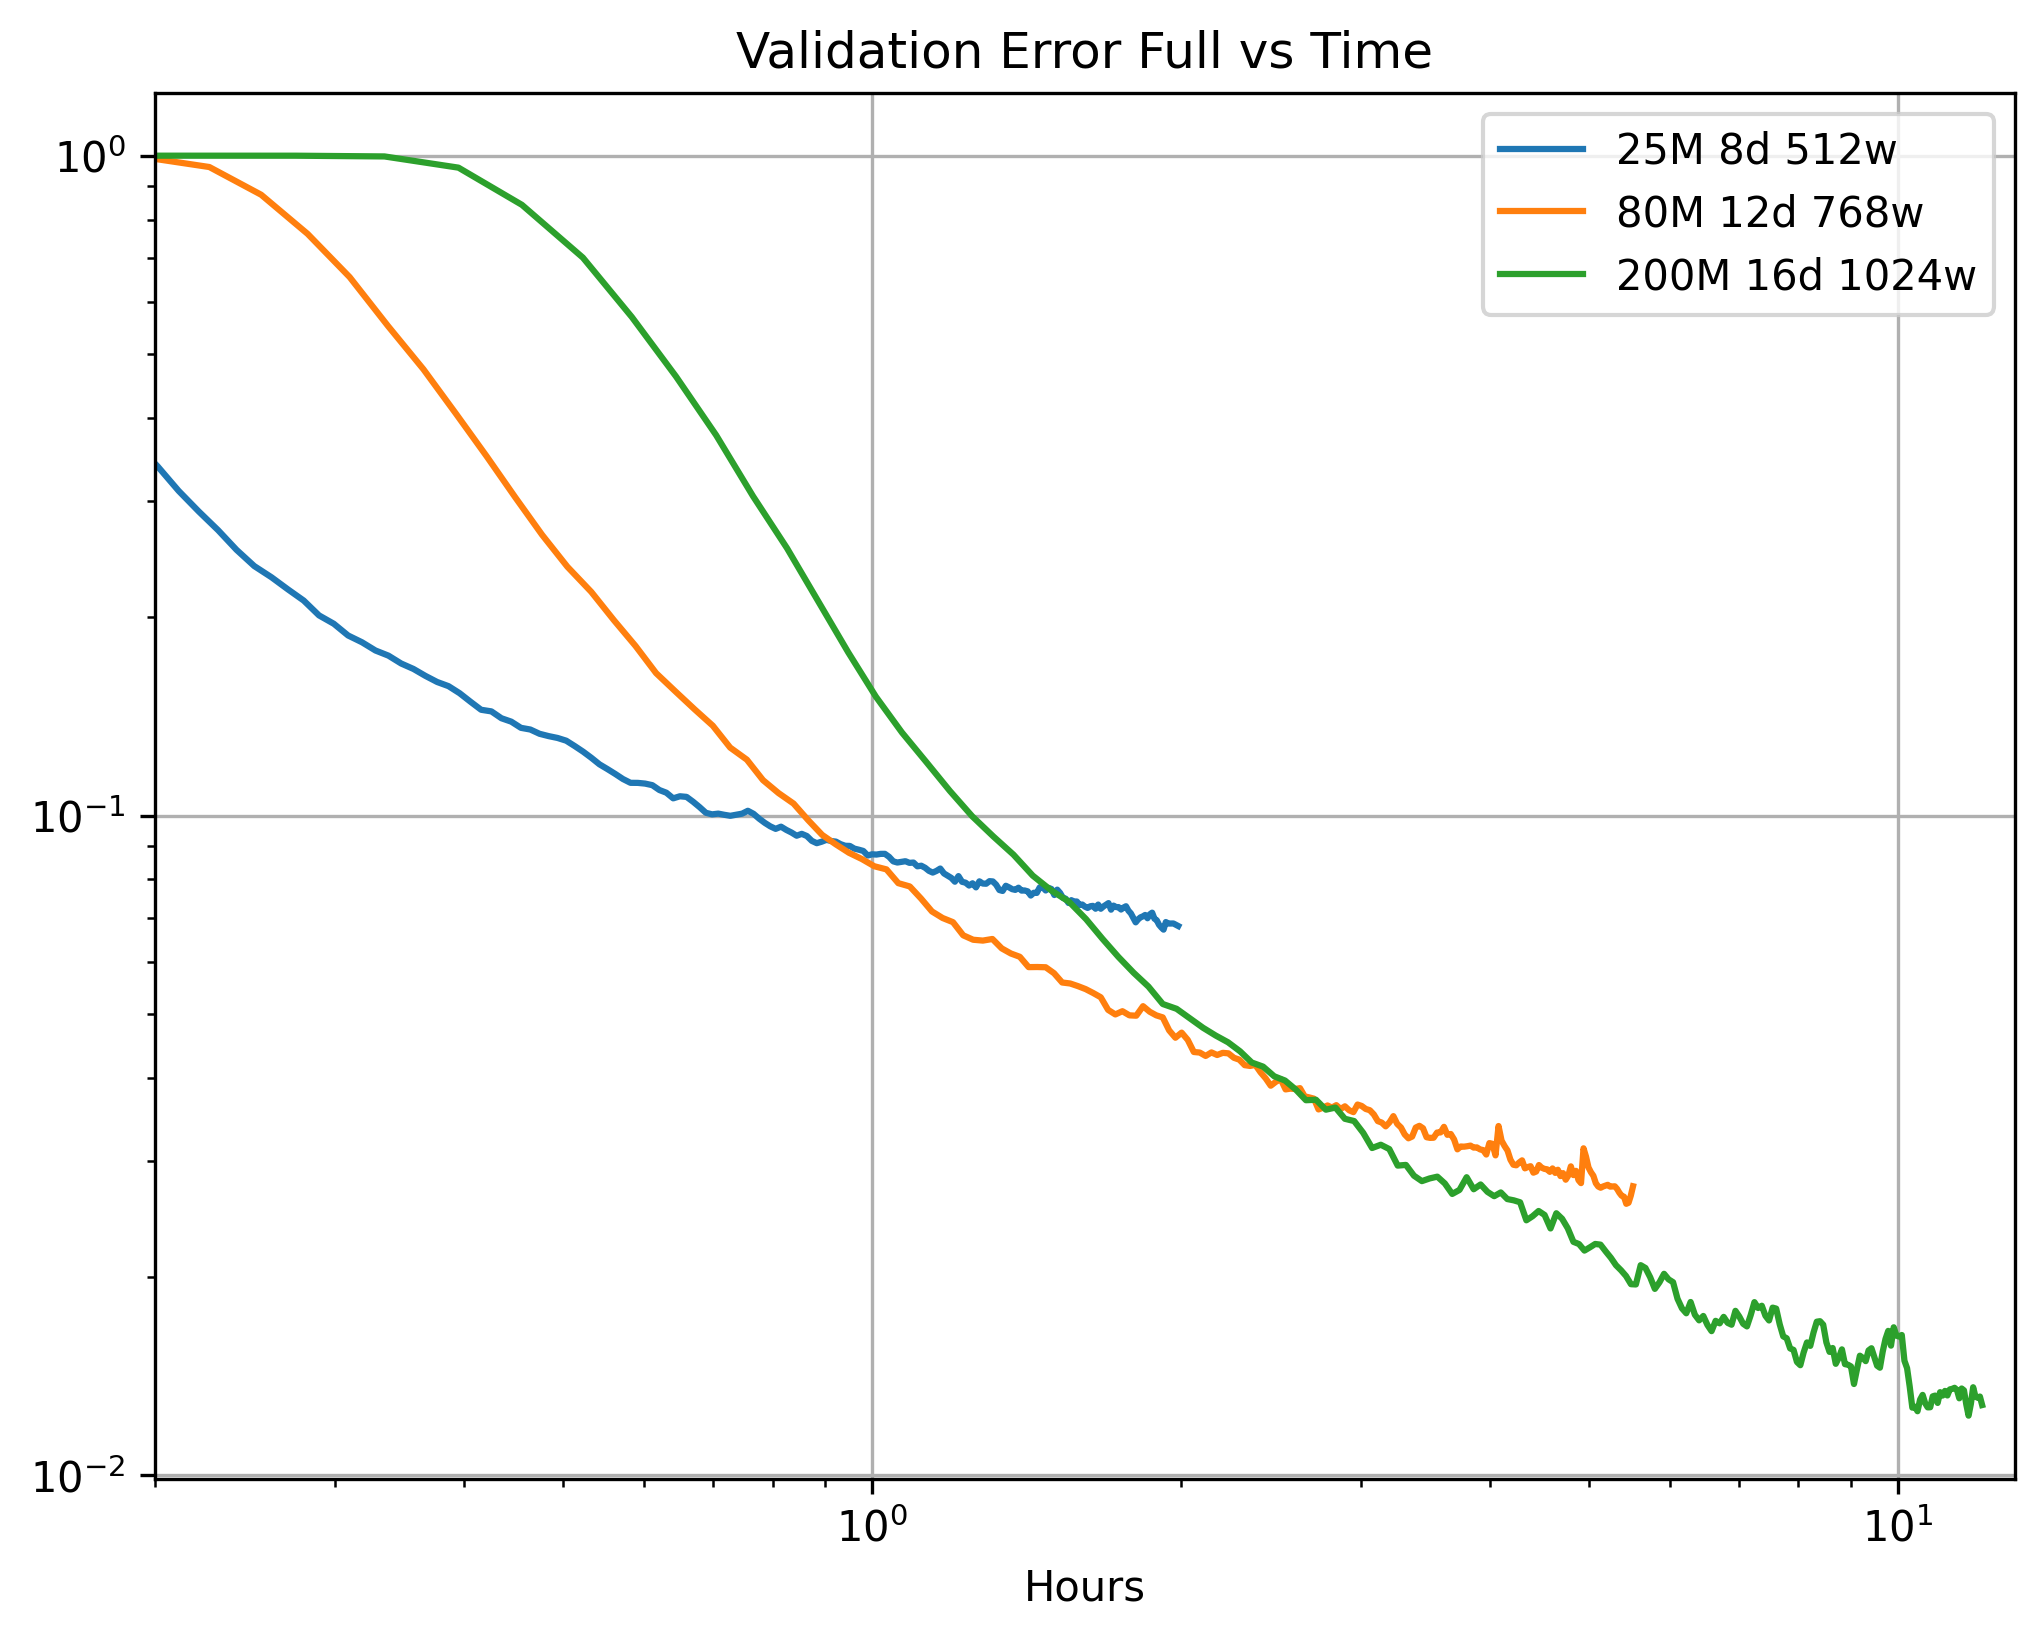

In [54]:
plt.figure(dpi=300, figsize=(8, 6))
plt.title("Validation Error Full vs Time")
plt.plot(df1["time"] / 3600, 1 - df1["valid_acc_full"].ewm(span=ewm_span).mean(), label="25M 8d 512w")
plt.plot(df2["time"] / 3600, 1 - df2["valid_acc_full"].ewm(span=ewm_span).mean(), label="80M 12d 768w")
plt.plot(df3["time"] / 3600, 1 - df3["valid_acc_full"].ewm(span=ewm_span).mean(), label="200M 16d 1024w")
plt.yscale("log")
plt.xlabel("Hours")
plt.xscale("log")
plt.xlim(0.2, 13)
plt.legend()
plt.grid()
plt.savefig("../img/valid_error_full_time.png")
plt.show()